# 3D Wireframe Visualization with Color Zones

This notebook creates a 3D wireframe plot with:
- Parallel cosine curves as the surface data
- Different colors for lines in different directions
- Color change at 60% through the z-axis (horizontal plane division)

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Enable interactive mode for matplotlib
%matplotlib widget

In [82]:
# Generate data for parallel cosine curves with more diverse shapes
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Amplitude scaling factor: starts small on left, grows toward right
# Maps X from [-2, 2] to [0.3, 1.0]
amplitude_scale = 0.3 + 0.7 * (X - x.min()) / (x.max() - x.min())

# Create cosine curves with amplitude that grows along X
Z = amplitude_scale * (
    np.cos(2 * np.pi * X) * (1 + 0.3 * Y)
    + 0.6 * np.cos(1.5 * np.pi * Y + 0.5 * X)
    + 0.3 * np.sin(3 * X * Y)
)

print(f"Data shapes - X: {X.shape}, Y: {Y.shape}, Z: {Z.shape}")
print(f"Z range: {Z.min():.2f} to {Z.max():.2f}")
print(
    f"Amplitude scale range: {amplitude_scale.min():.2f} to {amplitude_scale.max():.2f}"
)

Data shapes - X: (100, 100), Y: (100, 100), Z: (100, 100)
Z range: -1.77 to 2.16
Amplitude scale range: 0.30 to 1.00


In [ ]:
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


def plot_data(
    X,
    Y,
    Z,
    z_split_pct=0.6,
    cmap_x_below=LinearSegmentedColormap.from_list("custom", ["#00BFFF", "#0000CD"]),
    cmap_x_above=LinearSegmentedColormap.from_list("custom", ["#FFD700", "#DC143C"]),
    cmap_y_below=LinearSegmentedColormap.from_list("custom", ["#7FFF00", "#006400"]),
    cmap_y_above=LinearSegmentedColormap.from_list("custom", ["#FFA07A", "#FF4500"]),
):
    """
    Create a 3D wireframe plot with color zones split at a percentage of the z-axis.

    - X-direction lines: color varies with X position, hue varies with Z direction
    - Y-direction lines: color varies with Y position, hue varies with Z direction
    - Color changes at z_split_pct along the z-axis

    Parameters:
        X, Y, Z: 2D arrays from meshgrid defining the surface
        z_split_pct: percentage (0-1) along z-axis where color changes (default 0.6)
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Calculate the z-axis split value and ranges
    z_min, z_max = Z.min(), Z.max()
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()
    z_split_val = z_min + z_split_pct * (z_max - z_min)

    print(f"Z-axis range: {z_min:.2f} to {z_max:.2f}")
    print(f"{z_split_pct * 100:.0f}% split point: z = {z_split_val:.2f}")

    def plot_x_line_with_split(x_coords, y_coords, z_coords):
        """Plot X-direction line: gradient based on X, hue based on Z region."""
        for i in range(len(x_coords) - 1):
            x0, x1 = x_coords[i], x_coords[i + 1]
            y0, y1 = y_coords[i], y_coords[i + 1]
            z0, z1 = z_coords[i], z_coords[i + 1]

            # X position determines gradient position
            x_mid = (x0 + x1) / 2
            t_x = (x_mid - x_min) / (x_max - x_min) if x_max > x_min else 0.5

            below_0 = z0 < z_split_val
            below_1 = z1 < z_split_val

            if below_0 == below_1:
                cmap = cmap_x_below if below_0 else cmap_x_above
                ax.plot(
                    [x0, x1],
                    [y0, y1],
                    [z0, z1],
                    color=cmap(t_x),
                    linewidth=1.5,
                    alpha=0.9,
                )
            else:
                # Segment crosses threshold
                t = (z_split_val - z0) / (z1 - z0)
                x_cross = x0 + t * (x1 - x0)
                y_cross = y0 + t * (y1 - y0)
                z_cross = z_split_val

                t_x1 = ((x0 + x_cross) / 2 - x_min) / (x_max - x_min)
                t_x2 = ((x_cross + x1) / 2 - x_min) / (x_max - x_min)

                if below_0:
                    ax.plot(
                        [x0, x_cross],
                        [y0, y_cross],
                        [z0, z_cross],
                        color=cmap_x_below(t_x1),
                        linewidth=1.5,
                        alpha=0.9,
                    )
                    ax.plot(
                        [x_cross, x1],
                        [y_cross, y1],
                        [z_cross, z1],
                        color=cmap_x_above(t_x2),
                        linewidth=1.5,
                        alpha=0.9,
                    )
                else:
                    ax.plot(
                        [x0, x_cross],
                        [y0, y_cross],
                        [z0, z_cross],
                        color=cmap_x_above(t_x1),
                        linewidth=1.5,
                        alpha=0.9,
                    )
                    ax.plot(
                        [x_cross, x1],
                        [y_cross, y1],
                        [z_cross, z1],
                        color=cmap_x_below(t_x2),
                        linewidth=1.5,
                        alpha=0.9,
                    )

    def plot_y_line_with_split(x_coords, y_coords, z_coords):
        """Plot Y-direction line: gradient based on Y, hue based on Z region."""
        for i in range(len(y_coords) - 1):
            x0, x1 = x_coords[i], x_coords[i + 1]
            y0, y1 = y_coords[i], y_coords[i + 1]
            z0, z1 = z_coords[i], z_coords[i + 1]

            # Y position determines gradient position
            y_mid = (y0 + y1) / 2
            t_y = (y_mid - y_min) / (y_max - y_min) if y_max > y_min else 0.5

            below_0 = z0 < z_split_val
            below_1 = z1 < z_split_val

            if below_0 == below_1:
                cmap = cmap_y_below if below_0 else cmap_y_above
                ax.plot(
                    [x0, x1],
                    [y0, y1],
                    [z0, z1],
                    color=cmap(t_y),
                    linewidth=1.5,
                    alpha=0.9,
                )
            else:
                # Segment crosses threshold
                t = (z_split_val - z0) / (z1 - z0)
                x_cross = x0 + t * (x1 - x0)
                y_cross = y0 + t * (y1 - y0)
                z_cross = z_split_val

                t_y1 = ((y0 + y_cross) / 2 - y_min) / (y_max - y_min)
                t_y2 = ((y_cross + y1) / 2 - y_min) / (y_max - y_min)

                if below_0:
                    ax.plot(
                        [x0, x_cross],
                        [y0, y_cross],
                        [z0, z_cross],
                        color=cmap_y_below(t_y1),
                        linewidth=1.5,
                        alpha=0.9,
                    )
                    ax.plot(
                        [x_cross, x1],
                        [y_cross, y1],
                        [z_cross, z1],
                        color=cmap_y_above(t_y2),
                        linewidth=1.5,
                        alpha=0.9,
                    )
                else:
                    ax.plot(
                        [x0, x_cross],
                        [y0, y_cross],
                        [z0, z_cross],
                        color=cmap_y_above(t_y1),
                        linewidth=1.5,
                        alpha=0.9,
                    )
                    ax.plot(
                        [x_cross, x1],
                        [y_cross, y1],
                        [z_cross, z1],
                        color=cmap_y_below(t_y2),
                        linewidth=1.5,
                        alpha=0.9,
                    )

    # Plot X-direction lines (rows)
    for i in range(X.shape[0]):
        plot_x_line_with_split(X[i, :], Y[i, :], Z[i, :])

    # Plot Y-direction lines (columns)
    for j in range(X.shape[1]):
        plot_y_line_with_split(X[:, j], Y[:, j], Z[:, j])

    # Add labels and title
    ax.set_xlabel("X Axis", fontsize=12)
    ax.set_ylabel("Y Axis", fontsize=12)
    ax.set_zlabel("Z Axis", fontsize=12)
    ax.set_title(
        f"3D Wireframe: Position Gradients + Z-Region Hues\nColor split at {z_split_pct * 100:.0f}% Z-axis",
        fontsize=14,
        pad=20,
    )

    # Add a horizontal plane indicator at the split point
    x_range = [X.min(), X.max()]
    y_range = [Y.min(), Y.max()]
    plane_x = np.array([[x_range[0], x_range[0]], [x_range[1], x_range[1]]])
    plane_y = np.array([[y_range[0], y_range[1]], [y_range[0], y_range[1]]])
    plane_z = np.array([[z_split_val, z_split_val], [z_split_val, z_split_val]])
    ax.plot_surface(plane_x, plane_y, plane_z, alpha=0.15, color="gray")

    # Add legend
    legend_elements = [
        Line2D(
            [0],
            [0],
            color=cmap_x_below(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_x_below(0.6),
            label="X-lines below",
        ),
        Line2D(
            [0],
            [0],
            color=cmap_x_above(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_x_above(0.6),
            label="X-lines above",
        ),
        Line2D(
            [0],
            [0],
            color=cmap_y_below(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_y_below(0.6),
            label="Y-lines below",
        ),
        Line2D(
            [0],
            [0],
            color=cmap_y_above(0.6),
            lw=2,
            marker="o",
            markersize=4,
            markerfacecolor=cmap_y_above(0.6),
            label="Y-lines above",
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            lw=2,
            alpha=0.3,
            label=f"{z_split_pct * 100:.0f}% Z split plane",
        ),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

    # Set viewing angle
    ax.view_init(elev=25, azim=45)

    plt.tight_layout()
    plt.show()

    return fig, ax


print("plot_data function defined.")

plot_data function defined.


Z-axis range: -1.77 to 2.16
60% split point: z = 0.59


/tmp/nix-shell.nQ6VTZ/ipykernel_37248/2255241864.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12, 8))


NameError: name 'colors_x_below' is not defined

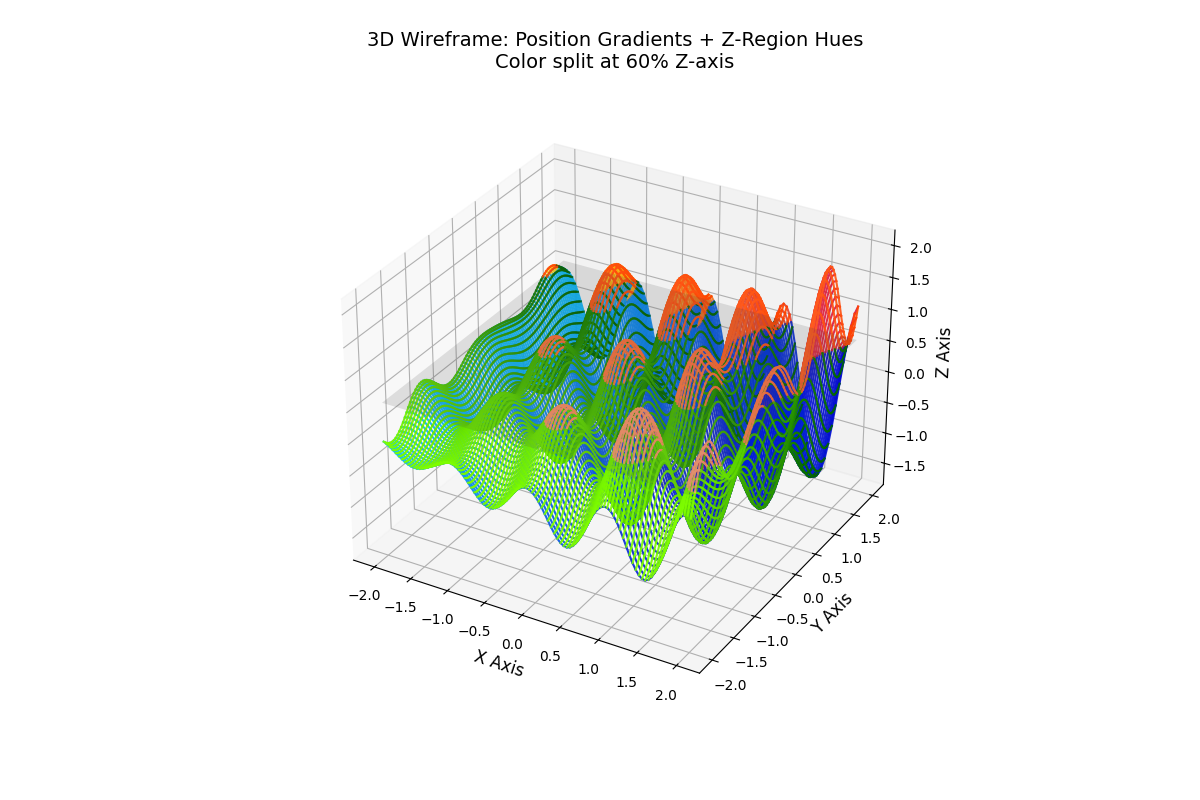

In [84]:
# Call the plotting function with our data
fig, ax = plot_data(X, Y, Z)

print("Plot displayed.")